# 機器學習入門實作流程

##專題背景與目標

本資料集用「抗藥性菌株資料」練習從資料到模型的完整流程。任務：預測是否屬於 MDR（多重抗藥，≥3 個家族耐藥）。

In [36]:
# === 匯入基本套件 ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt  # 資料處理與繪圖
from pathlib import Path  # 處理路徑（讀取/儲存檔案時很方便）

# === 匯入 Scikit-learn 模組 ===
# 模型訓練與驗證
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve

# 前處理：類別編碼、遺漏值補齊
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# 常用的機器學習模型
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier  # 集成樹模型（常見於分類任務）
from sklearn.linear_model import LogisticRegression  # 羅吉斯回歸（線性基準模型）

# 評估指標與報告
from sklearn.metrics import (
    classification_report,   # 分類結果摘要（Precision、Recall、F1）
    confusion_matrix,        # 混淆矩陣（觀察分類錯誤情況）
    accuracy_score,          # 準確率
    f1_score                 # F1分數（兼顧精確率與靈敏度）
)

# === 一般設定 ===
import warnings
warnings.filterwarnings("ignore")  # 忽略不影響執行的警告訊息（讓輸出更乾淨）
plt.rcParams.update({'figure.max_open_warning': 0})  # 避免多張圖時的警告訊息


In [37]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
# !wget -O TaipeiSansTCBeta-Regular.ttf https://cmuph.vghtced.com.tw/hub/user-redirect/lab/tree/TaipeiSansTCBeta-Regular.ttf

import matplotlib

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

# 1.資料收集與準備（Data Collection & Preparation）

資料來自 [Kaggle](https://www.kaggle.com/datasets)

資料集名稱:[Multi-Resistance Antibiotic Susceptibility](https://www.kaggle.com/datasets/adilimadeddinehosni/multi-resistance-antibiotic-susceptibility/data)

也可改讀本機上傳的 CSV。注意欄位名稱可能含縮寫與不同語言。

In [38]:
!pip install kagglehub[pandas-datasets]  #下載Kaggle資料集套件

In [39]:
import pandas as pd  # 確保有匯入 pandas

# 修改成你上傳的檔案名稱
file_path = "dementia_patients_health_data.csv"

# 如果是 csv 檔
df = pd.read_csv(file_path)

# 如果是 Excel 檔 (xlsx)，請改用下面這行
# df = pd.read_excel(file_path)

# 檢查資料是否讀取成功
print("資料欄位名稱：", df.columns)
df.head()

資料欄位名稱： Index(['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel',
       'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription',
       'Dosage in mg', 'Age', 'Education_Level', 'Dominant_Hand', 'Gender',
       'Family_History', 'Smoking_Status', 'APOE_ε4', 'Physical_Activity',
       'Depression_Status', 'Cognitive_Test_Scores', 'Medication_History',
       'Nutrition_Diet', 'Sleep_Quality', 'Chronic_Health_Conditions',
       'Dementia'],
      dtype='object')


,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [40]:
df.shape

(1000, 24)



# 2.探索性資料分析（Exploratory Data Analysis, EDA）

In [41]:
# 1️⃣ 基本結構與型態檢查
print("資料筆數與欄位數:", df.shape)
print("\n資料欄位：", df.columns.tolist())
print("\n欄位型別與缺失值概況：")
df.info()


資料筆數與欄位數: (1000, 24)

資料欄位： ['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel', 'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription', 'Dosage in mg', 'Age', 'Education_Level', 'Dominant_Hand', 'Gender', 'Family_History', 'Smoking_Status', 'APOE_ε4', 'Physical_Activity', 'Depression_Status', 'Cognitive_Test_Scores', 'Medication_History', 'Nutrition_Diet', 'Sleep_Quality', 'Chronic_Health_Conditions', 'Dementia']

欄位型別與缺失值概況：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Diabetic                   1000 non-null   int64  
 1   AlcoholLevel               1000 non-null   float64
 2   HeartRate                  1000 non-null   int64  
 3   BloodOxygenLevel           1000 non-null   float64
 4   BodyTemperature            1000 non-null   float64
 5   Weight                     1000 non-null   float64
 6  

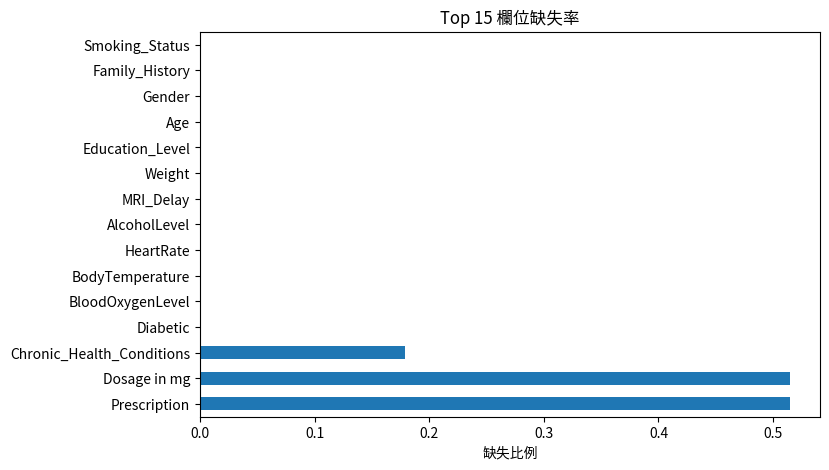

In [42]:
#  缺失值分析
missing = df.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
missing.head(15).plot.barh()
plt.title("Top 15 欄位缺失率")
plt.xlabel("缺失比例")
plt.show()

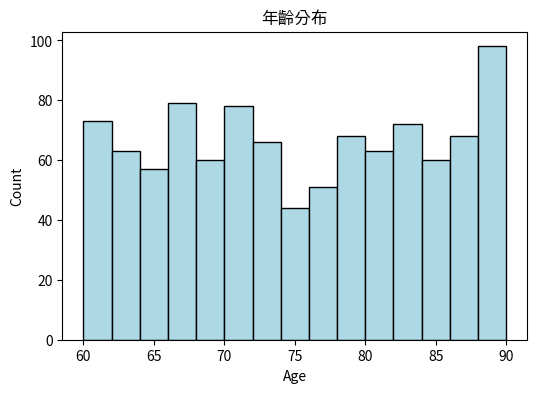

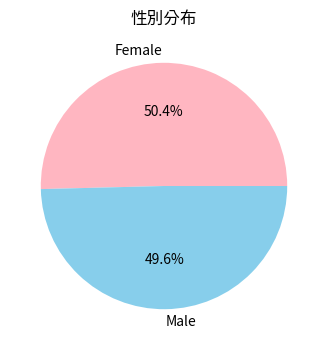

In [43]:
# 年齡與性別結構分析
# 先將 age/gender 分成兩個欄位
if 'age/gender' in df.columns:
    df[['Age','Gender']] = df['age/gender'].str.split('/', expand=True)
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

plt.figure(figsize=(6,4))
df['Age'].dropna().plot.hist(bins=15, color='lightblue', edgecolor='black')
plt.title('年齡分布')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(4,4))
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#FFB6C1','#87CEEB'])
plt.title('性別分布')
plt.ylabel('')
plt.show()

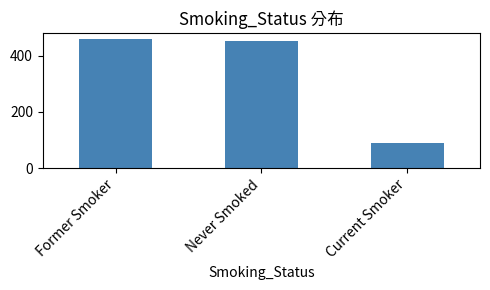

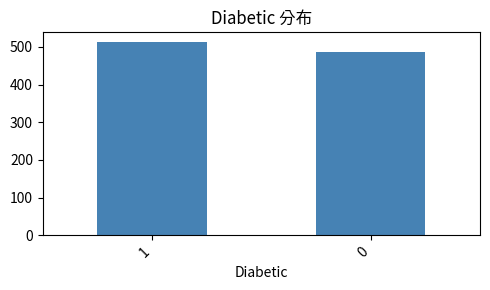

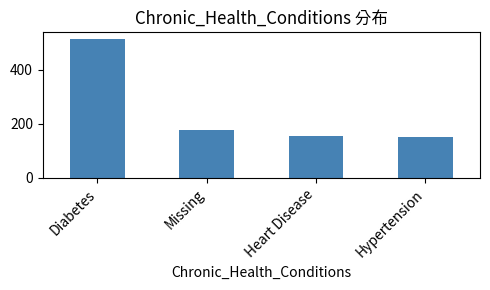

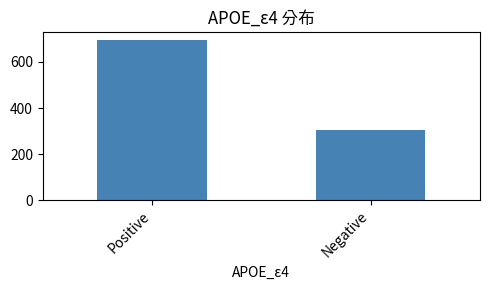

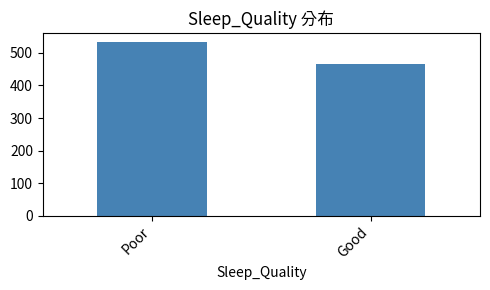

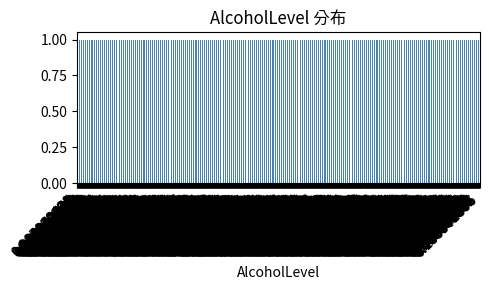

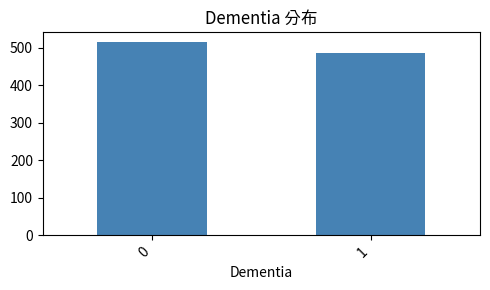

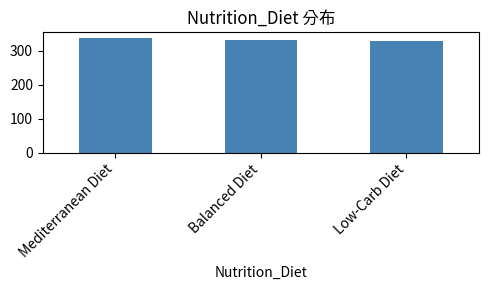

In [44]:
import matplotlib.pyplot as plt

# 臨床風險因子分布
cols = [
    'Smoking_Status','Diabetic','Chronic_Health_Conditions','APOE_ε4',
    'Sleep_Quality','AlcoholLevel','Dementia','Nutrition_Diet'
]


for c in cols:
    if c in df.columns:
        plt.figure(figsize=(5,3))

        s = df[c].copy()
        # ✅ 把缺失值標出來，避免都變成字串 'nan' 混淆
        s = s.astype("object").where(~s.isna(), other="Missing")

        s.value_counts(dropna=False).plot.bar(color='steelblue')
        plt.title(f'{c} 分布')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


# 3.資料前處理（Data Preprocessing）

In [50]:
# ==========================================
# 🛠️ [資料前處理 Data Preprocessing - 完整流程版]
# ==========================================

import pandas as pd
import numpy as np

# ------------------------------------------
# 1. 欄位偵測與基礎特徵轉換 (建立二元與等級變數)
# ------------------------------------------
# A. 自動偵測 APOE4 原始欄位名稱並建立 0/1 變數
apoe_col = [c for c in df.columns if 'APOE' in c.upper() or 'GENE' in c.upper()]
apoe_col = apoe_col[0] if apoe_col else 'APOE4'
df['APOE4_Positive'] = df[apoe_col].apply(lambda x: 1 if str(x).strip() in ['1', '1.0', 'True', 'Yes', 'Positive'] else 0)

# B. 自動偵測 Sleep 欄位名稱並建立 0/1 變數
sleep_col = [c for c in df.columns if 'SLEEP' in c.upper()]
sleep_col = sleep_col[0] if sleep_col else 'Sleep_Quality'
df['Good_Sleep_Quality'] = df[sleep_col].apply(lambda x: 1 if str(x).strip() in ['1', '1.0', 'Good', 'True', 'Yes'] else 0)

# C. 抽菸風險等級 (0:未抽, 1:已戒, 2:抽菸)
if 'Smoking_Status' in df.columns:
    smoke_map = {'Never Smoked': 0, 'Former Smoker': 1, 'Current Smoker': 2}
    df['Smoking_Status_Grade'] = df['Smoking_Status'].map(smoke_map).fillna(0).astype(int)

# D. 酒精暴露等級 (按 BAC 0.08 切分: 0:無, 1:低風險, 2:高風險)
if 'AlcoholLevel' in df.columns:
    df['Alcohol_Risk_Level'] = df['AlcoholLevel'].apply(
        lambda x: 2 if pd.to_numeric(x, errors='coerce') >= 0.08 else (1 if pd.to_numeric(x, errors='coerce') > 0 else 0)
    )

# E. 慢性病有無 (0/1)
if 'Chronic_Health_Conditions' in df.columns:
    df['Has_Chronic_Condition'] = df['Chronic_Health_Conditions'].apply(
        lambda x: 1 if pd.notna(x) and str(x).strip().lower() not in ['', 'nan', 'none', 'false', '0'] else 0
    )

# F. 地中海飲食 (0/1) - 剔除 Diet_Quality_Grade，僅保留地中海飲食
if 'Nutrition_Diet' in df.columns:
    df['Is_Mediterranean_Diet'] = df['Nutrition_Diet'].apply(
        lambda x: 1 if str(x).strip() == 'Mediterranean Diet' else 0
    )

# G. 發炎風險指標 (0~3 分 與 高發炎門檻 0/1)
df['Inflammatory_Risk_Score'] = (
    (df['Smoking_Status_Grade'] == 2).astype(int) + 
    (df['Alcohol_Risk_Level'] == 2).astype(int) + 
    df['Has_Chronic_Condition']
)
df['High_Inflammation_Risk'] = (df['Inflammatory_Risk_Score'] >= 1).astype(int)

# ------------------------------------------
# 2. 定義基礎特徵清單 (base_feature_cols) 與 目標變數
# ------------------------------------------
target_col = 'Dementia'

base_feature_cols = [
    'Age',
    'Good_Sleep_Quality',
    'APOE4_Positive',
    'Smoking_Status_Grade',
    'Alcohol_Risk_Level',
    'Has_Chronic_Condition',
    'Is_Mediterranean_Diet',
    'Inflammatory_Risk_Score',
    'High_Inflammation_Risk'
]

# ------------------------------------------
# 3. 前處理結果檢查：資料預覽 (Data Preview)
# ------------------------------------------
print("="*60)
print("✅ [步驟 1] 資料前處理完成！轉換後資料集前 5 筆預覽：")
print("="*60)
display(df[base_feature_cols + [target_col]].head())

# ------------------------------------------
# 4. 前處理結果檢查：缺失值分析 (Missing Value Analysis)
# ------------------------------------------
print("\n" + "="*60)
print("🔍 [步驟 2] 前處理後基礎特徵之缺失值檢查 (Missing Values)：")
print("="*60)
missing_summary = df[base_feature_cols + [target_col]].isnull().sum().to_frame(name='Missing_Count')
missing_summary['Missing_Percentage (%)'] = (missing_summary['Missing_Count'] / len(df)) * 100
display(missing_summary)

# ------------------------------------------
# 5. 前處理結果檢查：特徵數值分佈 (Value Distribution Analysis)
# ------------------------------------------
print("\n" + "="*60)
print("📊 [步驟 3] 前處理後各類別/等級特徵之次數與比例分佈 (Value Counts)：")
print("="*60)

for col in base_feature_cols:
    if col != 'Age': # Age 為連續變數，其餘為類別/二元變數
        print(f"\n--- [{col} 分佈情況] ---")
        counts = df[col].value_counts().to_frame(name='Count')
        counts['Percentage (%)'] = (df[col].value_counts(normalize=True) * 100).round(2)
        display(counts)

✅ [步驟 1] 資料前處理完成！轉換後資料集前 5 筆預覽：


,Age,Good_Sleep_Quality,APOE4_Positive,Smoking_Status_Grade,Alcohol_Risk_Level,Has_Chronic_Condition,Is_Mediterranean_Diet,Inflammatory_Risk_Score,High_Inflammation_Risk,Dementia
0,60,0,0,2,2,1,0,3,1,0
1,61,0,1,1,1,1,0,1,1,1
2,69,0,0,1,1,1,1,1,1,0
3,78,0,0,0,2,1,0,2,1,1
4,77,1,1,0,2,1,0,2,1,1



🔍 [步驟 2] 前處理後基礎特徵之缺失值檢查 (Missing Values)：


,Missing_Count,Missing_Percentage (%)
Age,0,0.0
Good_Sleep_Quality,0,0.0
APOE4_Positive,0,0.0
Smoking_Status_Grade,0,0.0
Alcohol_Risk_Level,0,0.0
Has_Chronic_Condition,0,0.0
Is_Mediterranean_Diet,0,0.0
Inflammatory_Risk_Score,0,0.0
High_Inflammation_Risk,0,0.0
Dementia,0,0.0



📊 [步驟 3] 前處理後各類別/等級特徵之次數與比例分佈 (Value Counts)：

--- [Good_Sleep_Quality 分佈情況] ---


...

,Count,Percentage (%)
Is_Mediterranean_Diet,,
0,662,66.2
1,338,33.8



--- [Inflammatory_Risk_Score 分佈情況] ---


,Count,Percentage (%)
Inflammatory_Risk_Score,,
2,478,47.8
1,431,43.1
0,52,5.2
3,39,3.9



--- [High_Inflammation_Risk 分佈情況] ---


,Count,Percentage (%)
High_Inflammation_Risk,,
1,948,94.8
0,52,5.2


In [52]:
# ==========================================
# 📊 [敘述統計 Descriptive Statistics]
# (針對前處理完成之 9 大基礎特徵與目標變數)
# ==========================================

import pandas as pd

# 1. 統整欲進行敘述統計的欄位 (9大基礎特徵 + Dementia)
summary_cols = [c for c in base_feature_cols if c in df.columns]
if target_col in df.columns:
    summary_cols.append(target_col)

# 2. 生成全變數之數值敘述統計表 (describe)
print("="*60)
print("📊 [模型基礎特徵與目標變數之敘述統計摘要 (Descriptive Statistics)]")
print("="*60)

stats_summary = df[summary_cols].describe().T
stats_summary = stats_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(stats_summary.round(3))

📊 [模型基礎特徵與目標變數之敘述統計摘要 (Descriptive Statistics)]


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,74.908,9.095,60.0,67.0,75.0,83.0,90.0
Good_Sleep_Quality,1000.0,0.466,0.499,0.0,0.0,0.0,1.0,1.0
APOE4_Positive,1000.0,0.694,0.461,0.0,0.0,1.0,1.0,1.0
Smoking_Status_Grade,1000.0,0.638,0.641,0.0,0.0,1.0,1.0,2.0
Alcohol_Risk_Level,1000.0,1.593,0.492,1.0,1.0,2.0,2.0,2.0
Has_Chronic_Condition,1000.0,0.821,0.384,0.0,1.0,1.0,1.0,1.0
Is_Mediterranean_Diet,1000.0,0.338,0.473,0.0,0.0,0.0,1.0,1.0
Inflammatory_Risk_Score,1000.0,1.504,0.658,0.0,1.0,2.0,2.0,3.0
High_Inflammation_Risk,1000.0,0.948,0.222,0.0,1.0,1.0,1.0,1.0
Dementia,1000.0,0.485,0.500,0.0,0.0,0.0,1.0,1.0


## [EDA - 相關性分析矩陣]

從相關矩陣可以觀察到，臨床特徵（例如年齡、糖尿病、住院史等）與多重抗藥性（MDR）之間的線性關係並不強。  
然而，這並不代表這些變數對抗藥性沒有影響。實際上，抗藥性往往是多個臨床與微生物因子交互作用的結果。

因此，我們會採用能處理**非線性關係**的機器學習模型（例如 **Random Forest**、**XGBoost** 等），  
以捕捉這些複雜的潛在關聯，進一步提升預測能力。


In [48]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


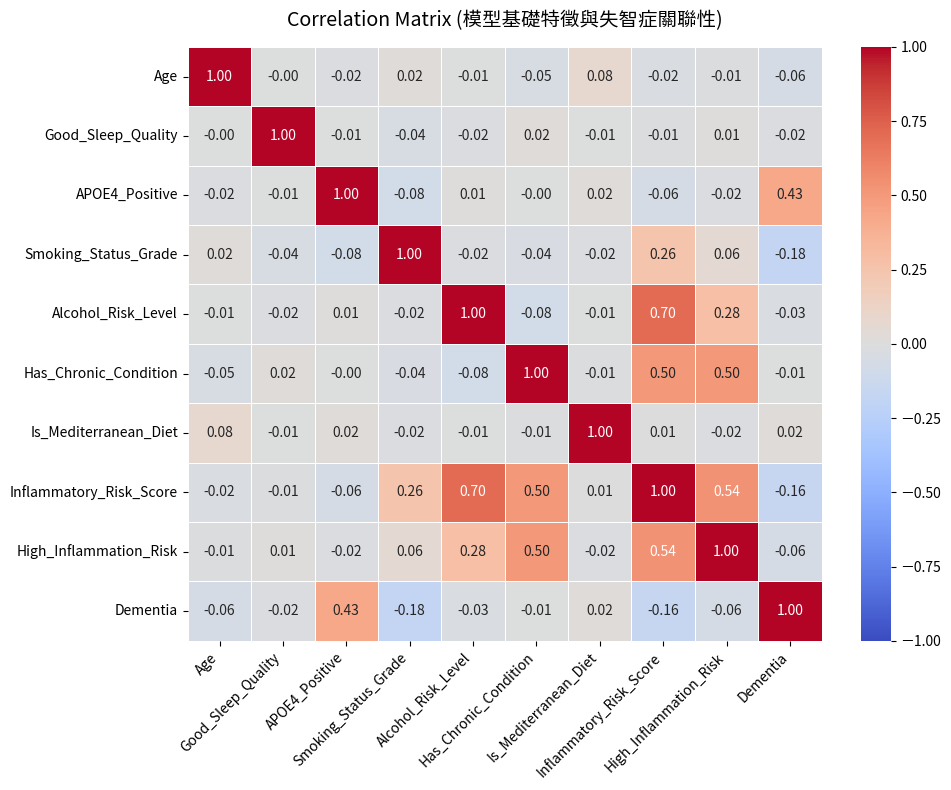

In [53]:
# ==========================================
# 📊 [EDA - Correlation Matrix 相關性矩陣]
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# 1. 統整欲計算相關性的欄位 (9大基礎特徵 + Dementia)
eda_cols = [c for c in base_feature_cols if c in df.columns]
if target_col in df.columns:
    eda_cols.append(target_col)

# 2. 計算 Pearson 相關係數矩陣
corr_data = df[eda_cols]
corr_df = corr_data.corr(numeric_only=True)

# 3. 繪製 Heatmap 熱力圖
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title("Correlation Matrix (模型基礎特徵與失智症關聯性)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

📊 [二元特徵與失智症之 Phi 相關係數與卡方檢定結果]


,Binary_Feature,Phi_Coefficient,p_value
0,APOE4_Positive,0.4251,0.0000
1,Alcohol_Risk_Level,0.0249,0.4317
2,Is_Mediterranean_Diet,0.0193,0.5410
3,Has_Chronic_Condition,-0.0036,0.9100
4,Good_Sleep_Quality,-0.0181,0.5673
5,High_Inflammation_Risk,-0.0566,0.0735


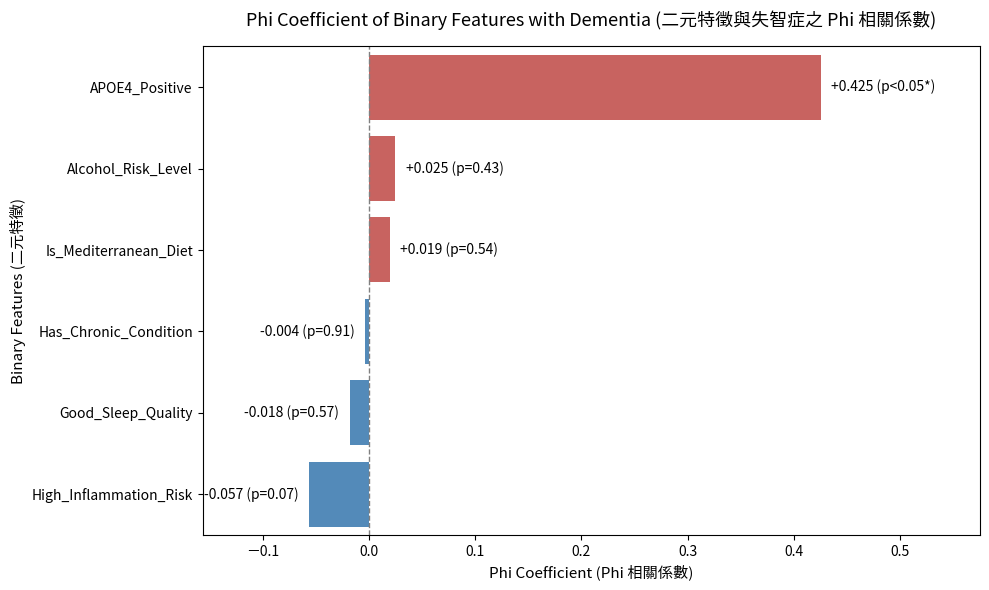

In [54]:
# ==========================================
# 📊 [EDA - 二元特徵 Phi 相關係數與卡方檢定]
# ==========================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. 自動從基礎特徵中篩選出二元變數 (0/1 特徵)
binary_cols = [c for c in base_feature_cols if c in df.columns and df[c].nunique() == 2]

phi_results = []

for col in binary_cols:
    if target_col in df.columns:
        # 建立 2x2 交叉表
        ct = pd.crosstab(df[col], df[target_col])
        if ct.shape == (2, 2):
            # 卡方檢定
            chi2, p, dof, ex = chi2_contingency(ct)
            n = ct.sum().sum()
            
            # 計算 Phi 係數絕對值
            phi = np.sqrt(chi2 / n)
            
            # 判斷方向性 (當特徵=1時，失智率是相對增加還是減少)
            p_dementia_given_1 = ct.loc[1, 1] / ct.loc[1].sum() if 1 in ct.index else 0
            p_dementia_given_0 = ct.loc[0, 1] / ct.loc[0].sum() if 0 in ct.index else 0
            
            if p_dementia_given_1 < p_dementia_given_0:
                phi = -phi
                
            phi_results.append({
                'Binary_Feature': col,
                'Phi_Coefficient': phi,
                'p_value': p
            })

phi_df = pd.DataFrame(phi_results).sort_values(by='Phi_Coefficient', ascending=False).reset_index(drop=True)

# 2. 顯示數據摘要表格
print("="*60)
print("📊 [二元特徵與失智症之 Phi 相關係數與卡方檢定結果]")
print("="*60)
display(phi_df.round(4))

# 3. 繪製條形圖
plt.figure(figsize=(10, 6))
colors = ['#d9534f' if x > 0 else '#428bca' for x in phi_df['Phi_Coefficient']]

ax = sns.barplot(
    data=phi_df,
    x='Phi_Coefficient',
    y='Binary_Feature',
    palette=colors
)

plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# 在圖表上標示數值與顯著性 (p-value)
for i, row in phi_df.iterrows():
    val = row['Phi_Coefficient']
    p_str = " (p<0.05*)" if row['p_value'] < 0.05 else f" (p={row['p_value']:.2f})"
    text_label = f"{val:+.3f}{p_str}"
    
    offset = 0.01 if val >= 0 else -0.01
    ha_align = 'left' if val >= 0 else 'right'
    
    ax.text(
        val + offset, 
        i, 
        text_label, 
        va='center', 
        ha=ha_align, 
        fontsize=10, 
        fontweight='bold'
    )

plt.title("Phi Coefficient of Binary Features with Dementia (二元特徵與失智症之 Phi 相關係數)", fontsize=13, pad=15)
plt.xlabel("Phi Coefficient (Phi 相關係數)", fontsize=11)
plt.ylabel("Binary Features (二元特徵)", fontsize=11)

x_min, x_max = phi_df['Phi_Coefficient'].min(), phi_df['Phi_Coefficient'].max()
plt.xlim(x_min - 0.1, x_max + 0.15)

plt.tight_layout()
plt.show()

# 4.特徵工程（Feature Engineering）

*   特徵選擇、轉換、降維或新特徵生成

*   提升模型表現與可解釋性


In [55]:
# ==========================================
# ⚙️ [特徵工程 Feature Engineering]
# ==========================================

import pandas as pd
import numpy as np

# 1. 複製前處理好的 DataFrame，保護 Raw Data
df_feat = df.copy()

# 2. 建構唯一的核心工程交互特徵 (Interaction Feature)
# 基因帶原 x 高發炎風險 (0/1)
if 'APOE4_Positive' in df_feat.columns and 'High_Inflammation_Risk' in df_feat.columns:
    df_feat['APOE4_x_HighInflammation'] = (
        df_feat['APOE4_Positive'] * df_feat['High_Inflammation_Risk']
    ).astype(int)

# 3. 彙整最終進入模型的 10 大精準特徵清單 (X_cols)
X_cols = base_feature_cols + ['APOE4_x_HighInflammation']

# 確保選取之欄位皆存在於 df_feat 中
X_cols = [c for c in X_cols if c in df_feat.columns]

# 4. 建立特徵矩陣 X 與目標變數向量 y
X = df_feat[X_cols].copy()
y = df_feat[target_col].copy()

# ------------------------------------------
# 5. 特徵工程結果檢查與預覽
# ------------------------------------------
print("="*60)
print("✅ [特徵工程建構完成]")
print("="*60)
print(f"🔹 特徵矩陣形狀 (X shape) : {X.shape} (共 {X.shape[0]} 筆資料，{X.shape[1]} 個特徵)")
print(f"🔹 目標變數形狀 (y shape) : {y.shape}")
print(f"🔹 最終選用的 10 大特徵清單 ：\n{X_cols}\n")

print("[前 5 筆特徵矩陣 X 預覽]:")
display(X.head())

print("\n[特徵矩陣 X 之缺失值檢查]:")
print(f"缺失值總數: {X.isnull().sum().sum()} 筆")

✅ [特徵工程建構完成]
🔹 特徵矩陣形狀 (X shape) : (1000, 10) (共 1000 筆資料，10 個特徵)
🔹 目標變數形狀 (y shape) : (1000,)
🔹 最終選用的 10 大特徵清單 ：
['Age', 'Good_Sleep_Quality', 'APOE4_Positive', 'Smoking_Status_Grade', 'Alcohol_Risk_Level', 'Has_Chronic_Condition', 'Is_Mediterranean_Diet', 'Inflammatory_Risk_Score', 'High_Inflammation_Risk', 'APOE4_x_HighInflammation']

[前 5 筆特徵矩陣 X 預覽]:


,Age,Good_Sleep_Quality,APOE4_Positive,Smoking_Status_Grade,Alcohol_Risk_Level,Has_Chronic_Condition,Is_Mediterranean_Diet,Inflammatory_Risk_Score,High_Inflammation_Risk,APOE4_x_HighInflammation
0,60,0,0,2,2,1,0,3,1,0
1,61,0,1,1,1,1,0,1,1,1
2,69,0,0,1,1,1,1,1,1,0
3,78,0,0,0,2,1,0,2,1,0
4,77,1,1,0,2,1,0,2,1,1



[特徵矩陣 X 之缺失值檢查]:
缺失值總數: 0 筆


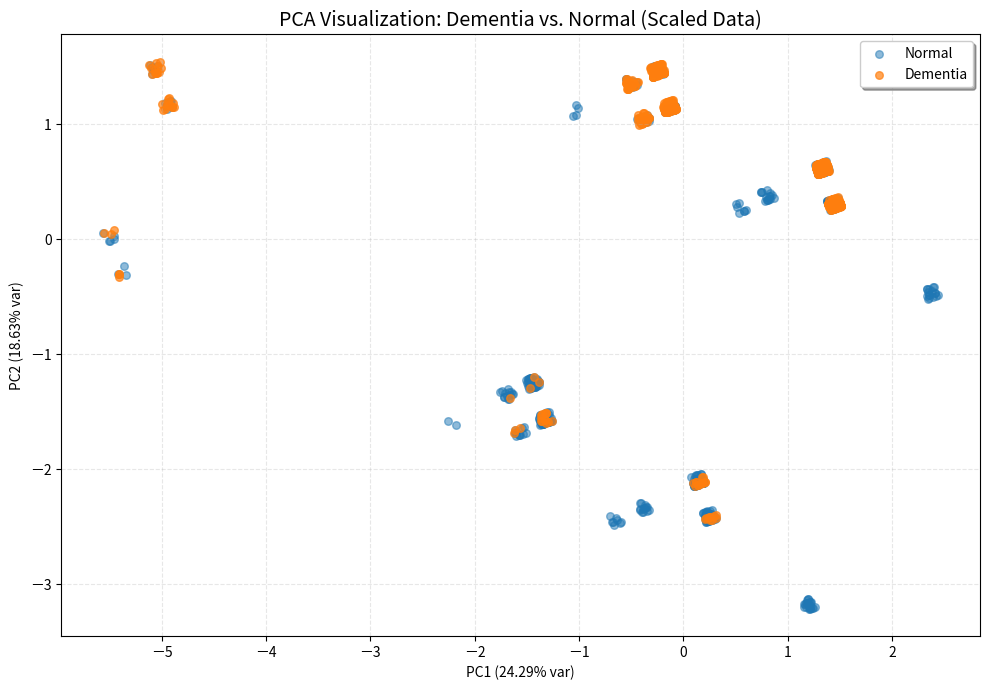

----------------------------------------
各主成分解釋變異比例：
PC1: 24.29%
PC2: 18.63%
累積解釋變異：42.93%
----------------------------------------

影響 PC1 最大的前 5 個特徵：
  Inflammatory_Risk_Score: 0.5422 (+) (loading=0.5422)
  High_Inflammation_Risk: 0.4939 (+) (loading=0.4939)
  Has_Chronic_Condition: 0.3851 (+) (loading=0.3851)
  Alcohol_Risk_Level  : 0.3710 (+) (loading=0.3710)
  APOE4_x_HighInflammation: 0.3595 (+) (loading=0.3595)

影響 PC2 最大的前 5 個特徵：
  APOE4_Positive      : 0.6722 (+) (loading=0.6722)
  APOE4_x_HighInflammation: 0.5952 (+) (loading=0.5952)
  Inflammatory_Risk_Score: 0.3031 (-) (loading=-0.3031)
  Smoking_Status_Grade: 0.1994 (-) (loading=-0.1994)
  Alcohol_Risk_Level  : 0.1892 (-) (loading=-0.1892)


In [59]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 使用特徵工程產生的 X, y（未 Oversample）
X_pca_input = X.copy()
y_pca_input = pd.to_numeric(y.copy(), errors='coerce')

# 預防轉型後出現 NaN 導致索引不對齊
valid_mask = y_pca_input.notna()
X_pca_input = X_pca_input.loc[valid_mask]
y_pca_input = y_pca_input.loc[valid_mask].astype(int)

# 1️⃣ 資料標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

# 2️⃣ PCA（2D）
pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

# 3️⃣ 繪圖
plt.figure(figsize=(10, 7))

mask0 = (y_pca_input.values == 0)
mask1 = (y_pca_input.values == 1)

plt.scatter(X_pca_2d[mask0, 0], X_pca_2d[mask0, 1], label='Normal', alpha=0.5, s=30)
plt.scatter(X_pca_2d[mask1, 0], X_pca_2d[mask1, 1], label='Dementia', alpha=0.7, s=30)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} var)")
plt.title("PCA Visualization: Dementia vs. Normal (Scaled Data)", fontsize=14, fontweight='bold')
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 4️⃣ 解釋變異
print("-" * 40)
print("各主成分解釋變異比例：")
for i, v in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {v:.2%}")
print(f"累積解釋變異：{pca.explained_variance_ratio_.sum():.2%}")
print("-" * 40)

# 5️⃣ 提取 PC1 與 PC2 Top 5 特徵 Loadings
loadings_df = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=X_pca_input.columns
)

for col in ['PC1', 'PC2']:
    print(f"\n影響 {col} 最大的前 5 個特徵：")
    top_5 = loadings_df[col].abs().sort_values(ascending=False).head(5)
    for feat in top_5.index:
        val = loadings_df.loc[feat, col]
        direction = "(+)" if val > 0 else "(-)"
        print(f"  {feat:<20}: {abs(val):.4f} {direction} (loading={val:.4f})")


#5.資料拆分與交叉驗證（Data Splitting & Cross-Validation）

* 首先使用 `train_test_split()` 將資料切分為 80% 的訓練集與 20% 的測試集，並採用 `stratify=y` 的分層抽樣方式，確保訓練與測試集中
「Non-MDR」與「MDR」兩類的比例一致。



* 由於資料中 MDR（多重抗藥）為少數類別，屬於類別不平衡問題，
因此在交叉驗證前，針對訓練集使用 **`RandomOverSampler`** 進行過採樣，
讓正負類的樣本數量更為平衡，以避免模型偏向預測多數類（Non-MDR）。


* 接著，在訓練資料上進行 **5 折分層交叉驗證（5-Fold Stratified Cross-Validation）**，讓每個模型都能在不同資料子集上被訓練與驗證，提升模型泛化能力。



In [58]:
# ==========================================
# ✂️ [資料拆分與交叉驗證 Train-Test Split & CV]
# (完全對齊學長範本)
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold

# 1. 訓練集與測試集拆分 (80/20 比例 + 分層抽樣)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # 保持失智症目標變數的比率一致
)

# 2. 設定 5 折分層交叉驗證機制 (5-Fold Stratified CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. 輸出拆分結果與目標變數分佈檢查
print("="*60)
print("✅ [資料拆分完成]")
print("="*60)
print(f"🔹 原始總資料筆數 : {X.shape[0]} 筆")
print(f"🔹 訓練集 (X_train): {X_train.shape[0]} 筆 ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"🔹 測試集 (X_test) : {X_test.shape[0]} 筆 ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"🔹 特徵數量       : {X_train.shape[1]} 個")

print("\n" + "="*60)
print("📊 [訓練集與測試集之失智症 (Dementia) 比例對比]")
print("="*60)

train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Train_Set (%)': train_dist.round(1),
    'Test_Set (%)': test_dist.round(1)
})
dist_df.index.name = 'Dementia_Label'
display(dist_df)

✅ [資料拆分完成]
🔹 原始總資料筆數 : 1000 筆
🔹 訓練集 (X_train): 800 筆 (80%)
🔹 測試集 (X_test) : 200 筆 (20%)
🔹 特徵數量       : 10 個

📊 [訓練集與測試集之失智症 (Dementia) 比例對比]


,Train_Set (%),Test_Set (%)
Dementia_Label,,
0,51.5,51.5
1,48.5,48.5


In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1️⃣ 確保目標變數 y 為乾淨的 0/1 整數型態 (避免型態不一致)
y_clean = pd.to_numeric(y, errors='coerce').fillna(0).astype(int)

# 2️⃣ 資料切分 (Train 80% / Test 20%)，使用分層抽樣保持 Dementia 比例一致
Xtr, Xte, ytr, yte = train_test_split(
    X, y_clean, 
    test_size=0.2, 
    stratify=y_clean, 
    random_state=42
)

# 3️⃣ 印出切分後的資料形狀與目標變數比例
print("=" * 50)
print(f"✅ 資料拆分完成！")
print(f"訓練集 (Train Set) 數量: Xtr={Xtr.shape}, ytr={ytr.shape}")
print(f"測試集 (Test Set)  數量: Xte={Xte.shape}, yte={yte.shape}")
print("-" * 50)
print(f"訓練集失智症比例 (Dementia Rate in Train): {ytr.mean():.2%}")
print(f"測試集失智症比例 (Dementia Rate in Test) : {yte.mean():.2%}")
print("=" * 50)

✅ 資料拆分完成！
訓練集 (Train Set) 數量: Xtr=(800, 10), ytr=(800,)
測試集 (Test Set)  數量: Xte=(200, 10), yte=(200,)
--------------------------------------------------
訓練集失智症比例 (Dementia Rate in Train): 48.50%
測試集失智症比例 (Dementia Rate in Test) : 48.50%


In [62]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]
Note: you may need to restart the kernel to use updated packages.


📊 Oversample 前 (Train Set 類別分佈):
Dementia
Normal      412
Dementia    388
Name: count, dtype: int64

Proportion:
Dementia
Normal      51.5%
Dementia    48.5%
Name: count, dtype: object


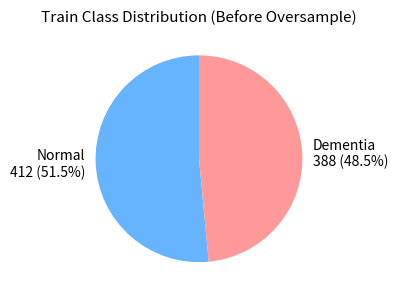


📊 Oversample 後 (Train Set 類別分佈):
Dementia
Dementia    412
Normal      412
Name: count, dtype: int64

Proportion:
Dementia
Dementia    50.0%
Normal      50.0%
Name: count, dtype: object


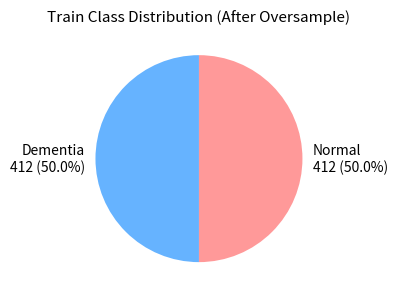


📐 資料矩陣形狀確認 (Shapes):
原始訓練集: Xtr = (800, 10), ytr = (800,)
平衡訓練集: Xtr_over = (824, 10), ytr_over = (824,)


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler

# -------- 1. Oversample 前 --------
print("=" * 50)
print("📊 Oversample 前 (Train Set 類別分佈):")
counts_before = pd.Series(ytr).value_counts().rename({0: 'Normal', 1: 'Dementia'})
props_before = counts_before / counts_before.sum()

print(counts_before)
print("\nProportion:")
print((props_before * 100).round(2).astype(str) + "%")

# 圓餅圖（Oversample 前）
plt.figure(figsize=(4, 4))
plt.pie(
    counts_before,
    labels=[f"{lbl}\n{cnt} ({pct:.1f}%)" for lbl, cnt, pct in zip(counts_before.index, counts_before, props_before*100)],
    autopct=None,
    startangle=90,
    colors=['#66b3ff', '#ff9999']
)
plt.title("Train Class Distribution (Before Oversample)", fontsize=11)
plt.tight_layout()
plt.show()


# -------- 2. 執行 RandomOverSampler --------
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
Xtr_over, ytr_over = ros.fit_resample(Xtr, ytr)


# -------- 3. Oversample 後 --------
print("\n" + "=" * 50)
print("📊 Oversample 後 (Train Set 類別分佈):")
counts_after = pd.Series(ytr_over).value_counts().rename({0: 'Normal', 1: 'Dementia'})
props_after = counts_after / counts_after.sum()

print(counts_after)
print("\nProportion:")
print((props_after * 100).round(2).astype(str) + "%")

# 圓餅圖（Oversample 後）
plt.figure(figsize=(4, 4))
plt.pie(
    counts_after,
    labels=[f"{lbl}\n{cnt} ({pct:.1f}%)" for lbl, cnt, pct in zip(counts_after.index, counts_after, props_after*100)],
    autopct=None,
    startangle=90,
    colors=['#66b3ff', '#ff9999']
)
plt.title("Train Class Distribution (After Oversample)", fontsize=11)
plt.tight_layout()
plt.show()


# -------- 4. 確認矩陣形狀並覆蓋訓練資料 --------
print("\n" + "=" * 50)
print("📐 資料矩陣形狀確認 (Shapes):")
print(f"原始訓練集: Xtr = {Xtr.shape}, ytr = {ytr.shape}")
print(f"平衡訓練集: Xtr_over = {Xtr_over.shape}, ytr_over = {ytr_over.shape}")
print("=" * 50)

# 最後覆蓋訓練資料，供後續模型訓練使用
Xtr, ytr = Xtr_over, ytr_over

In [65]:
# [交叉驗證設定]：分層 5 折，隨機打亂以穩定估計
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 我們在 Xtr / ytr 上做交叉驗證（保留 Xte / yte 作為最終獨立測試）

# 6.模型選擇（Model Selection）

使用羅吉斯回歸、隨機森林和ExtraTrees來進行建模，當中可以調整超參數來調整
目前示範的三種基礎模型：

1. 羅吉斯回歸（Logistic Regression）



  *   最簡單的二元分類模型，能提供清楚的特徵權重解釋。


  *   適合初學者了解「輸入特徵對結果的線性影響」。



2. 隨機森林（Random Forest）

* 以「多棵決策樹」組成的集成模型（Ensemble Model），能捕捉非線性關係。

* 不需要太多資料前處理，抗雜訊能力強，是醫學類資料分析的常見基線模型。

3. 極端隨機森林（ExtraTrees Classifier）

* 與隨機森林類似，但在分裂節點時更隨機。

* 通常能更快訓練、略減過擬合，適合當作隨機森林的對照模型。


In [68]:
pip install xgboost lightgbm catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 5.3 MB/s  0:00:25m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 2.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.2/97.2 MB 3.5 MB/s  0:00:27m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 3.7 MB/s  0:01:38m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 5.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [catboost]6/7 [catboost]
Note: you may need to restart the kernel to use updated packages.


In [69]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 2️⃣ 定義 6 大分類模型字典
clfs = {
    # Logistic Regression：線性基準模型
    "LogReg": LogisticRegression(
        max_iter=500, 
        random_state=42
    ),

    # Random Forest：隨機森林，適合表格與非線性特徵
    "RF": RandomForestClassifier(
        n_estimators=150, 
        random_state=42
    ),

    # Extra Trees：極端隨機樹，速度快且對抗過擬合能力強
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=150, 
        random_state=42
    ),

    # XGBoost：梯度提升樹，加入 eval_metric 避免版本警告
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        eval_metric='logloss',
        random_state=42
    ),

    # LightGBM：輕量快速梯度提升樹，加入 verbose=-1 保持輸出乾淨
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=-1,
        verbose=-1,
        random_state=42
    ),

    # CatBoost：類別友善梯度提升樹
    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_seed=42
    )
}

print(f"✅ 模型字典建立完成，共準備了 {len(clfs)} 個分類模型！")

✅ 模型字典建立完成，共準備了 6 個分類模型！


# 7.模型訓練與優化（Model Training & Optimization）
可以調整模型的超參數後來交叉驗證時，找出最好的超參數

In [70]:
# === [分層 5 折交叉驗證]：對每個模型計算 CV Accuracy / F1 / AUROC ===
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score

print("=" * 65)
print("🔄 正在對訓練集 (TRAIN) 進行 5 折分層交叉驗證 (Stratified 5-Fold CV)...")
print("=" * 65)

cv_rows = []

for name, clf in clfs.items():
    # 1. Accuracy (交叉驗證平均與標準差)
    acc_scores = cross_val_score(clf, Xtr, ytr, cv=skf, scoring='accuracy')
    
    # 2. F1-score (兼顧 Precision 與 Recall)
    f1_scores = cross_val_score(clf, Xtr, ytr, cv=skf, scoring='f1')

    # 3. ROC AUC (排序與分類能力)
    try:
        auc_scores = cross_val_score(clf, Xtr, ytr, cv=skf, scoring='roc_auc')
        auc_mean, auc_std = auc_scores.mean(), auc_scores.std()
    except Exception:
        auc_mean, auc_std = np.nan, np.nan

    cv_rows.append({
        "Model": name,
        "CV Acc (mean±std)": f"{acc_scores.mean():.3f} ± {acc_scores.std():.3f}",
        "CV F1 (mean±std)": f"{f1_scores.mean():.3f} ± {f1_scores.std():.3f}",
        "CV AUC (mean±std)": f"{auc_mean:.3f} ± {auc_std:.3f}" if not np.isnan(auc_mean) else "NA"
    })

# 轉成 DataFrame 表格呈現在畫面上
cv_table = pd.DataFrame(cv_rows).set_index("Model")
print("\n【5-Fold Stratified CV Evaluation Results on TRAIN】")
display(cv_table)

🔄 正在對訓練集 (TRAIN) 進行 5 折分層交叉驗證 (Stratified 5-Fold CV)...

【5-Fold Stratified CV Evaluation Results on TRAIN】


,CV Acc (mean±std),CV F1 (mean±std),CV AUC (mean±std)
Model,,,
LogReg,0.745 ± 0.022,0.780 ± 0.014,0.757 ± 0.021
RF,0.681 ± 0.027,0.697 ± 0.025,0.744 ± 0.014
ExtraTrees,0.666 ± 0.021,0.676 ± 0.022,0.697 ± 0.033
XGBoost,0.710 ± 0.019,0.719 ± 0.024,0.752 ± 0.017
LightGBM,0.693 ± 0.030,0.705 ± 0.032,0.746 ± 0.017
CatBoost,0.704 ± 0.028,0.720 ± 0.032,0.761 ± 0.022


#8.模型測試與評估（Model Testing & Evaluation）


*   用測試集驗證最終模型的準確率、召回率、F1-score、AUC 等指標
*   檢查是否過擬合或偏差太高




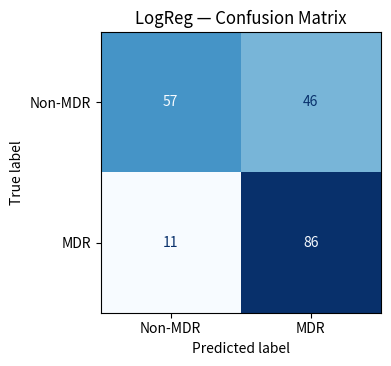


================ LogReg 評估報告 ================
Test Acc: 0.715 | Test F1: 0.751
              precision    recall  f1-score   support

     Non-MDR       0.84      0.55      0.67       103
         MDR       0.65      0.89      0.75        97

    accuracy                           0.71       200
   macro avg       0.74      0.72      0.71       200
weighted avg       0.75      0.71      0.71       200



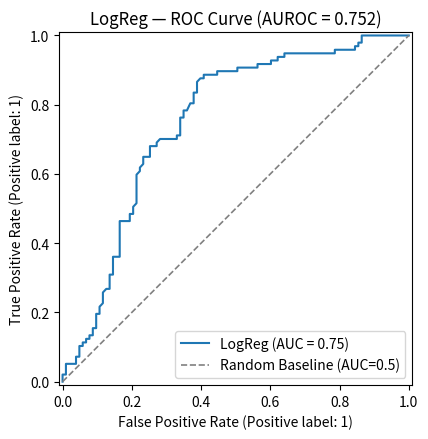

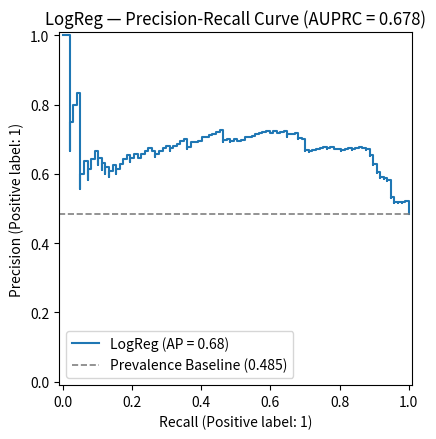

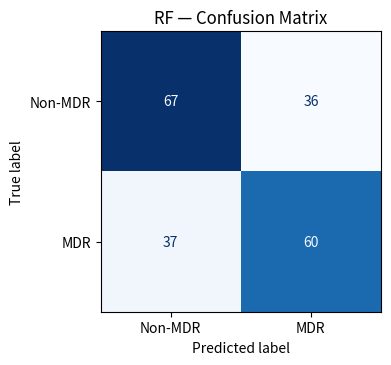


================ RF 評估報告 ================
Test Acc: 0.635 | Test F1: 0.622
              precision    recall  f1-score   support

     Non-MDR       0.64      0.65      0.65       103
         MDR       0.62      0.62      0.62        97

    accuracy                           0.64       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.64      0.63       200



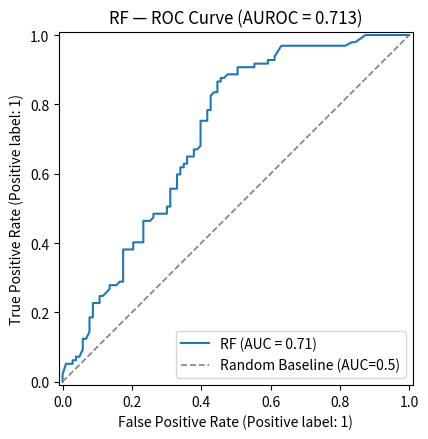

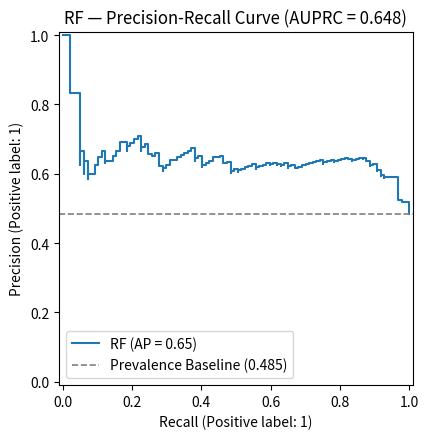

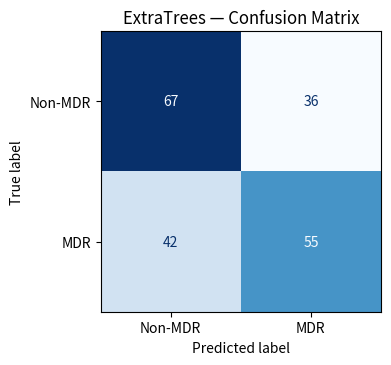


================ ExtraTrees 評估報告 ================
Test Acc: 0.610 | Test F1: 0.585
              precision    recall  f1-score   support

     Non-MDR       0.61      0.65      0.63       103
         MDR       0.60      0.57      0.59        97

    accuracy                           0.61       200
   macro avg       0.61      0.61      0.61       200
weighted avg       0.61      0.61      0.61       200



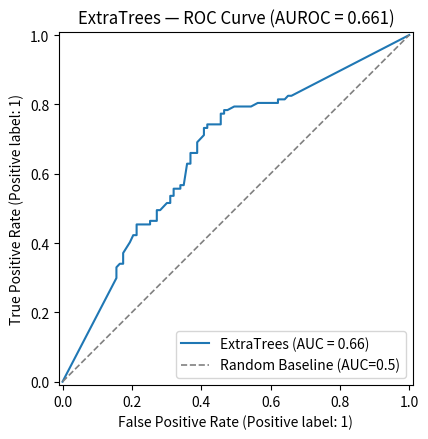

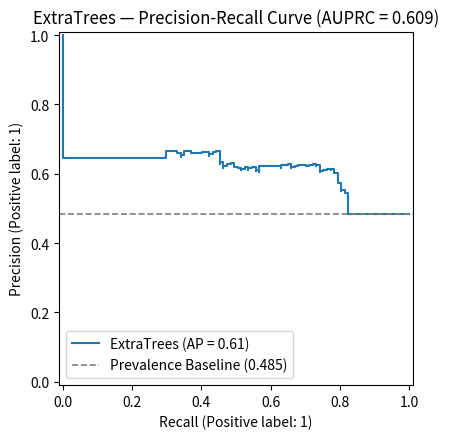

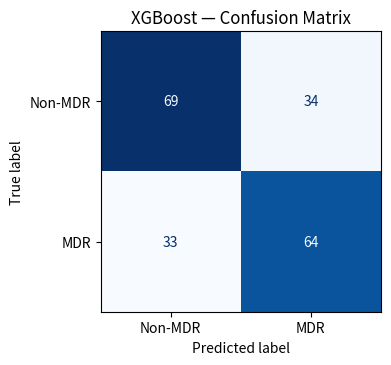


================ XGBoost 評估報告 ================
Test Acc: 0.665 | Test F1: 0.656
              precision    recall  f1-score   support

     Non-MDR       0.68      0.67      0.67       103
         MDR       0.65      0.66      0.66        97

    accuracy                           0.67       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.67      0.67      0.67       200



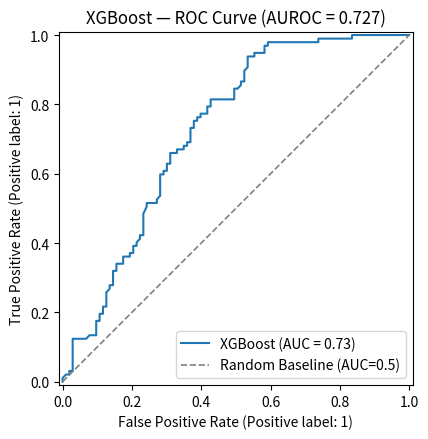

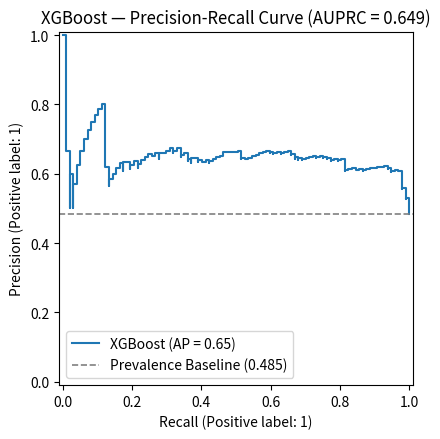

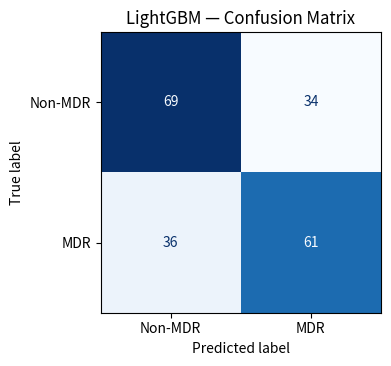


================ LightGBM 評估報告 ================
Test Acc: 0.650 | Test F1: 0.635
              precision    recall  f1-score   support

     Non-MDR       0.66      0.67      0.66       103
         MDR       0.64      0.63      0.64        97

    accuracy                           0.65       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.65      0.65      0.65       200



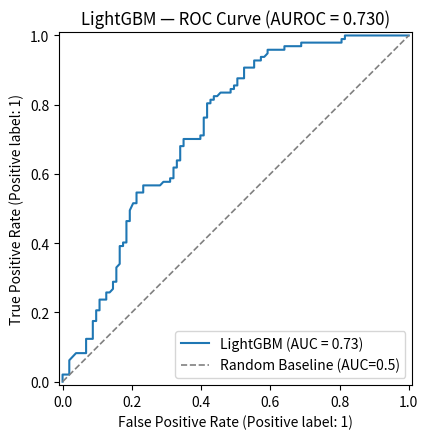

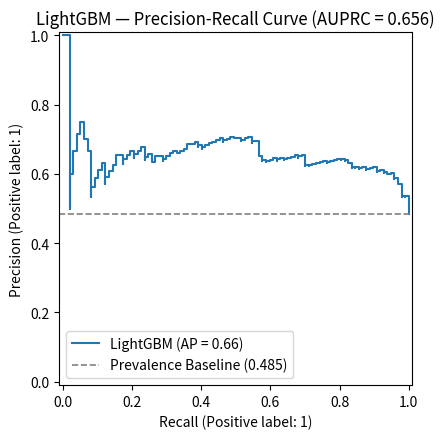

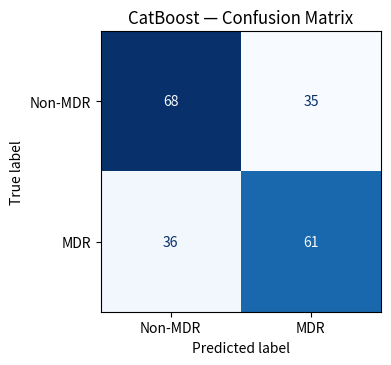


================ CatBoost 評估報告 ================
Test Acc: 0.645 | Test F1: 0.632
              precision    recall  f1-score   support

     Non-MDR       0.65      0.66      0.66       103
         MDR       0.64      0.63      0.63        97

    accuracy                           0.65       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.64      0.65      0.64       200



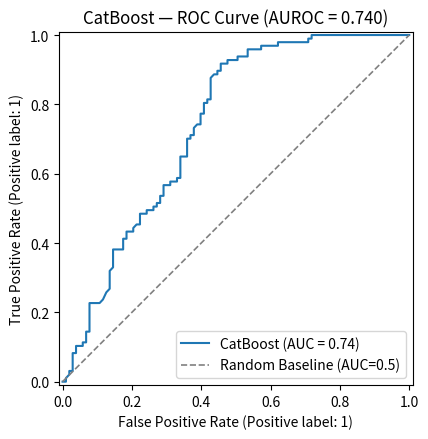

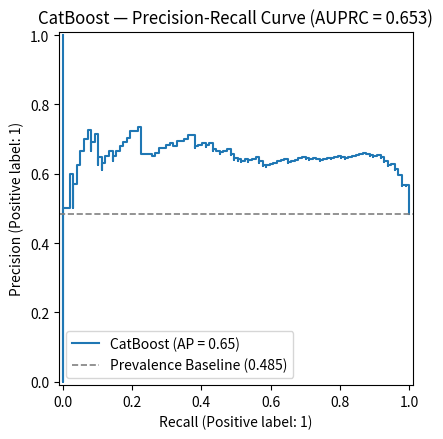

In [72]:
# 匯入所需模組
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay,
    precision_recall_curve, average_precision_score, PrecisionRecallDisplay,
    classification_report, accuracy_score, f1_score
)
import numpy as np
import matplotlib.pyplot as plt

# 儲存各模型評估結果
y_scores = {}
model_auc = {}
model_auprc = {}
model_f1 = {}
trained_models = {}

# 計算測試集中正例（MDR）的天然比例，作為 PRC 的基準線
baseline_prc = np.mean(yte)

# ---------------------------
# 模型訓練 + 評估 + 視覺化
# ---------------------------
for name, clf in clfs.items():
    clf.fit(Xtr, ytr)
    yp = clf.predict(Xte)

    # 嘗試取得連續分數（供 ROC / PRC 使用）
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(Xte)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_score = clf.decision_function(Xte)
    else:
        y_score = None

    trained_models[name] = clf

    # --- 1. 混淆矩陣 ---
    fig, ax = plt.subplots(figsize=(4, 4))
    cm = confusion_matrix(yte, yp, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-MDR', 'MDR'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    plt.close()

    # --- 2. 指標計算與文字報告 ---
    acc = accuracy_score(yte, yp)
    f1  = f1_score(yte, yp, zero_division=0)
    model_f1[name] = f1
    print(f"\n================ {name} 評估報告 ================")
    print(f"Test Acc: {acc:.3f} | Test F1: {f1:.3f}")
    print(classification_report(yte, yp, target_names=['Non-MDR', 'MDR'], zero_division=0))

    # --- 3. 曲線繪製 (ROC & PRC) ---
    if y_score is not None:
        y_scores[name] = y_score
        
        # --- ROC / AUROC ---
        auc = roc_auc_score(yte, y_score)
        model_auc[name] = auc

        fig, ax = plt.subplots(figsize=(5, 4.5))
        RocCurveDisplay.from_predictions(yte, y_score, ax=ax, name=name)
        # 加入隨機分類基準線（AUROC = 0.5）
        ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.2, label='Random Baseline (AUC=0.5)')
        ax.set_title(f"{name} — ROC Curve (AUROC = {auc:.3f})")
        ax.legend(loc='lower right')
        plt.tight_layout()
        plt.show()
        plt.close()

        # --- PRC / AUPRC ---
        auprc = average_precision_score(yte, y_score)
        model_auprc[name] = auprc

        fig, ax = plt.subplots(figsize=(5, 4.5))
        PrecisionRecallDisplay.from_predictions(yte, y_score, ax=ax, name=name)
        # 加入不平衡資料的機率基準線（AUPRC Baseline = 正例比例）
        ax.axhline(y=baseline_prc, color='gray', linestyle='--', linewidth=1.2, 
                   label=f'Prevalence Baseline ({baseline_prc:.3f})')
        ax.set_title(f"{name} — Precision-Recall Curve (AUPRC = {auprc:.3f})")
        ax.legend(loc='lower left')
        plt.tight_layout()
        plt.show()
        plt.close()
    else:
        print(f"[{name}] 無法計算連續分數，跳過 ROC/PRC 繪製。")

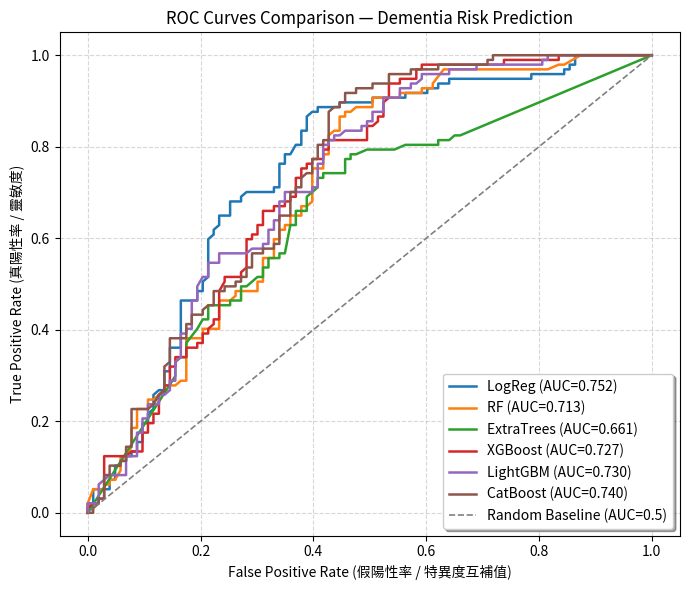

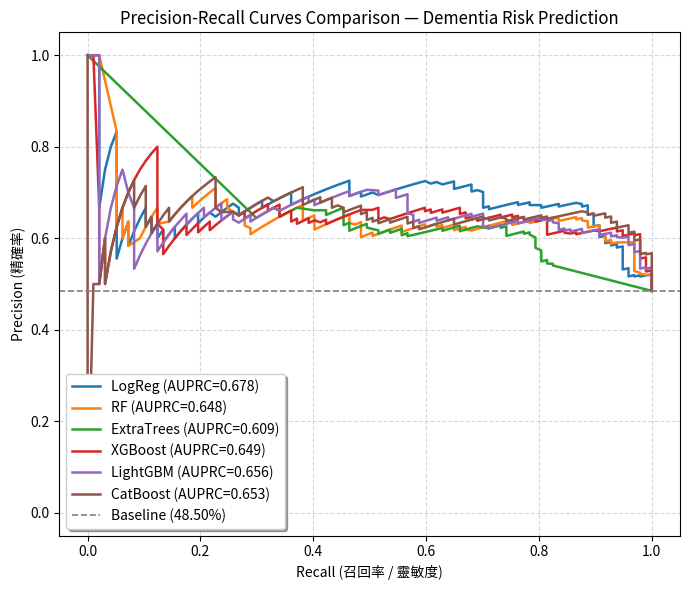

In [73]:
# ===============================================
# 📊 多模型綜合對照圖 (ROC & Precision-Recall 比較)
# ===============================================

if len(y_scores) > 0:
    # -----------------------------------------------
    # 1️⃣ 多模型 ROC 曲線對照圖 (AUROC Comparison)
    # -----------------------------------------------
    plt.figure(figsize=(7, 6))
    for name, y_score in y_scores.items():
        fpr, tpr, _ = roc_curve(yte, y_score)
        auc = roc_auc_score(yte, y_score)
        plt.plot(fpr, tpr, linewidth=1.8, label=f"{name} (AUC={auc:.3f})")

    # ➕ 加入隨機猜測基準線（AUROC = 0.5）
    plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.2, label='Random Baseline (AUC=0.5)')

    plt.xlabel("False Positive Rate (假陽性率 / 特異度互補值)")
    plt.ylabel("True Positive Rate (真陽性率 / 靈敏度)")
    plt.title("ROC Curves Comparison — Dementia Risk Prediction", fontsize=12, fontweight='bold')
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------
    # 2️⃣ 多模型 Precision-Recall 曲線對照圖 (AUPRC Comparison)
    # -----------------------------------------------
    plt.figure(figsize=(7, 6))
    for name, y_score in y_scores.items():
        precision, recall, _ = precision_recall_curve(yte, y_score)
        auprc = average_precision_score(yte, y_score)
        plt.plot(recall, precision, linewidth=1.8, label=f"{name} (AUPRC={auprc:.3f})")

    # ➕ 加入測試集 Dementia 盛行率基準線 (Prevalence Baseline)
    baseline_prc = np.mean(yte)
    plt.axhline(y=baseline_prc, color='gray', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_prc:.2%})')

    plt.xlabel("Recall (召回率 / 靈敏度)")
    plt.ylabel("Precision (精確率)")
    plt.title("Precision-Recall Curves Comparison — Dementia Risk Prediction", fontsize=12, fontweight='bold')
    plt.legend(loc="lower left", frameon=True, shadow=True)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ 沒有可繪製的預測分數 (y_scores)，無法繪製對照圖。")

In [75]:
# ===============================================
# 3. 最佳模型自動挑選邏輯
# ===============================================

if model_auc:
    # 階段 1：比對 AUROC
    best_auc = max(model_auc.values())
    candidates = [m for m, a in model_auc.items() if np.isclose(a, best_auc)]

    # 階段 2：若 AUROC 平手，比對 AUPRC
    if len(candidates) > 1:
        print(f"\n⚖️ 多個模型 AUROC 相同 ({best_auc:.3f})，以 AUPRC 比較...")
        best_auprc = max(model_auprc.get(m, 0) for m in candidates)
        candidates = [m for m in candidates if np.isclose(model_auprc.get(m, 0), best_auprc)]

        # 階段 3：若 AUPRC 也平手，比對 F1-score
        if len(candidates) > 1:
            print(f"⚖️ AUPRC 也相同，改以 F1-score 比較...")
            best_f1 = max(model_f1.get(m, 0) for m in candidates)
            candidates = [m for m in candidates if np.isclose(model_f1.get(m, 0), best_f1)]
            
            if len(candidates) > 1:
                print(f"⚠️ 三項指標皆相同，預設選擇第一個模型：{candidates[0]}")

    best_model_name = candidates[0]
    best_model = trained_models[best_model_name]
    
    print(f"\n🏆 最佳模型挑選結果：【{best_model_name}】")
    print(f"  • AUROC  = {model_auc[best_model_name]:.3f}")
    print(f"  • AUPRC  = {model_auprc[best_model_name]:.3f}")
    print(f"  • F1-score = {model_f1[best_model_name]:.3f}")
else:
    best_model_name, best_model = None, None
    print("❌ 無法挑選最佳模型，請確認 model_auc 不為空。")


🏆 最佳模型挑選結果：【LogReg】
  • AUROC  = 0.752
  • AUPRC  = 0.678
  • F1-score = 0.751


#9.模型部署 （Model Deployment）

In [76]:
# ===============================================
# 📦 Step 9: 儲存最佳模型與部署資料 (Model Deployment)
# ===============================================

if best_model is not None:
    import joblib, json, os, time

    # 1️⃣ 建立模型儲存資料夾
    save_dir = f"./best_model_{best_model_name.lower()}"
    os.makedirs(save_dir, exist_ok=True)

    # 2️⃣ 儲存最佳模型物件 (.joblib)
    model_path = f"{save_dir}/model.joblib"
    joblib.dump(best_model, model_path)

    # 3️⃣ 儲存模型詮釋資料 (Metadata JSON)
    meta = {
        "model_name": best_model_name,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "AUROC": float(model_auc[best_model_name]),
        "AUPRC": float(model_auprc.get(best_model_name, 0)),
        "F1_score": float(model_f1.get(best_model_name, 0)),
        "Train_size": len(ytr),
        "Test_size": len(yte)
    }
    with open(f"{save_dir}/metadata.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    # 4️⃣ 儲存特徵欄位名稱清單 (Feature Names JSON)
    feature_list = X.columns.tolist()
    with open(f"{save_dir}/feature_names.json", "w", encoding="utf-8") as f:
        json.dump(feature_list, f, ensure_ascii=False, indent=2)

    print("=" * 65)
    print(f"✅ 最佳模型【{best_model_name}】已成功部署並儲存至：{save_dir}")
    print(f"  • 模型檔 : {save_dir}/model.joblib")
    print(f"  • 元資料 : {save_dir}/metadata.json")
    print(f"  • 特徵檔 : {save_dir}/feature_names.json (共 {len(feature_list)} 個特徵)")
    print("=" * 65)
else:
    print("❌ 未檢測到最佳模型，請先執行前一步的最佳模型挑選程式碼。")

✅ 最佳模型【LogReg】已成功部署並儲存至：./best_model_logreg
  • 模型檔 : ./best_model_logreg/model.joblib
  • 元資料 : ./best_model_logreg/metadata.json
  • 特徵檔 : ./best_model_logreg/feature_names.json (共 10 個特徵)


In [77]:
# ===============================================
# 🔮 Step 9-2: 載入部署模型與單筆即時預測測試 (Inference Test)
# ===============================================

import joblib, json
import pandas as pd
import numpy as np

# 1️⃣ 載入已儲存的最佳模型與特徵名稱清單
model_loaded = joblib.load(f"{save_dir}/model.joblib")

with open(f"{save_dir}/feature_names.json", "r", encoding="utf-8") as f:
    feat_loaded = json.load(f)

# 2️⃣ 定義單筆/多筆字典資料即時預測函式
def predict_from_dict(d: dict):
    """
    d: 單筆或多筆樣本的 dict（key 是特徵名）
    例如：
    d = {
       "Age": [75], "Good_Sleep_Quality": [0], "APOE4_Positive": [1], 
       "Smoking_Status_Grade": [1], "Alcohol_Risk_Level": [2], ...
    }
    """
    df_new = pd.DataFrame(d)
    
    # 缺少的欄位自動補齊 NaN
    for c in feat_loaded:
        if c not in df_new.columns:
            df_new[c] = np.nan
            
    # 確保欄位名稱與順序與訓練時 100% 一致
    df_new = df_new[feat_loaded]

    # 取得機率與分類結果 (預設閾值 0.5)
    if hasattr(model_loaded, "predict_proba"):
        prob = model_loaded.predict_proba(df_new)[:, 1]
    else:
        prob = model_loaded.decision_function(df_new)
        
    pred = (prob >= 0.5).astype(int)
    return pred, prob


# -----------------------------------------------
# 🧪 3️⃣ 測試示範：拿測試集 (Xte) 前 3 筆資料模擬「新傳入的病人數據」
# -----------------------------------------------
sample = Xte.head(3).copy()

print("=" * 65)
print("🧫 模擬傳入的新病人數據樣本預覽 (Top 3 Samples)：")
print("=" * 65)
display(sample)

print("\n" + "=" * 65)
print("🔮 模型即時預測結果 (Real-time Prediction Results)：")
print("=" * 65)

# 對每筆樣本進行逐筆預測
for i in range(len(sample)):
    row_dict = sample.iloc[i].to_dict()

    # 呼叫預測函式
    pred, prob = predict_from_dict({k: [v] for k, v in row_dict.items()})

    # 修正輸出標籤為 Normal 與 Dementia
    label = "Dementia（失智症高風險）" if pred[0] == 1 else "Normal（正常/低風險）"
    confidence = prob[0]

    print(f"\n🧍‍♂️ 病人樣本 {i+1}:")
    print(f"  • 🔍 模型診斷預測：{label}")
    print(f"  • 💡 患病信心度 (Dementia Probability)：{confidence:.1%}")
    
print("=" * 65)

🧫 模擬傳入的新病人數據樣本預覽 (Top 3 Samples)：


,Age,Good_Sleep_Quality,APOE4_Positive,Smoking_Status_Grade,Alcohol_Risk_Level,Has_Chronic_Condition,Is_Mediterranean_Diet,Inflammatory_Risk_Score,High_Inflammation_Risk,APOE4_x_HighInflammation
749,90,0,1,0,1,1,1,1,1,1
679,70,1,0,0,2,1,0,2,1,0
758,87,0,1,1,2,1,0,2,1,1



🔮 模型即時預測結果 (Real-time Prediction Results)：

🧍‍♂️ 病人樣本 1:
  • 🔍 模型診斷預測：Dementia（失智症高風險）
  • 💡 患病信心度 (Dementia Probability)：69.4%

🧍‍♂️ 病人樣本 2:
  • 🔍 模型診斷預測：Normal（正常/低風險）
  • 💡 患病信心度 (Dementia Probability)：17.6%

🧍‍♂️ 病人樣本 3:
  • 🔍 模型診斷預測：Dementia（失智症高風險）
  • 💡 患病信心度 (Dementia Probability)：61.1%


In [78]:
# ===============================================
# 🧫 模擬平均典型樣本預測 (Scenario Simulation)
# ===============================================

import pandas as pd
import numpy as np

# 1️⃣ 建立「模擬典型樣本」：取測試集 (Xte) 前 10 筆樣本進行統計特徵合成
sample_df = Xte.head(10).copy()

# 將數值型與類別型欄位分開處理
num_cols = sample_df.select_dtypes(include=[np.number]).columns
cat_cols = [c for c in sample_df.columns if c not in num_cols]

# 數值欄位取中位數 (Median)
num_median = sample_df[num_cols].median(numeric_only=True)

# 類別/等級欄位取最常出現的值 (Mode)
cat_mode = sample_df[cat_cols].mode().iloc[0] if len(cat_cols) > 0 else pd.Series()

# 合併成一筆模擬典型樣本 (1 筆資料的 DataFrame)
median_sample = pd.concat([num_median, cat_mode])
median_sample = median_sample.to_frame().T

print("=" * 65)
print("🧫 合成之典型病人模擬樣本 (10 筆樣本之中位數/眾數):")
print("=" * 65)
display(median_sample)

# 2️⃣ 依據載入的特徵清單 (feat_loaded) 自動對齊欄位與補齊缺值
for c in feat_loaded:
    if c not in median_sample.columns:
        median_sample[c] = np.nan
median_sample = median_sample[feat_loaded]

# 3️⃣ 使用部署好的即時預測函式進行評估
pred, prob = predict_from_dict(median_sample.to_dict(orient="list"))

# 4️⃣ 結果呈現 (修正為 Dementia 標籤)
label = "Dementia（失智症高風險）" if pred[0] == 1 else "Normal（正常/低風險）"
confidence = prob[0]

print("\n" + "=" * 65)
print("🔮 典型模擬樣本診斷結果：")
print("=" * 65)
print(f"  • 🔍 模型預測診斷結果：{label}")
print(f"  • 💡 患病信心度 (Dementia Probability)：{confidence:.1%}")
print("=" * 65)

🧫 合成之典型病人模擬樣本 (10 筆樣本之中位數/眾數):


,Age,Good_Sleep_Quality,APOE4_Positive,Smoking_Status_Grade,Alcohol_Risk_Level,Has_Chronic_Condition,Is_Mediterranean_Diet,Inflammatory_Risk_Score,High_Inflammation_Risk,APOE4_x_HighInflammation
0,84.0,0.5,1.0,0.5,1.5,1.0,0.0,1.0,1.0,0.5



🔮 典型模擬樣本診斷結果：
  • 🔍 模型預測診斷結果：Dementia（失智症高風險）
  • 💡 患病信心度 (Dementia Probability)：76.1%


# 10.模型迭代與維護（Model Iteration & Maintenance）

*   根據新資料持續更新模型
*   檢測概念漂移（Concept Drift），確保長期準確性


